# Import Libraries

In [5]:
# Setup and Imports ---

import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#import missingno as msno # For visualizing missing data

# Get the current working directory of the notebook
notebook_dir = os.getcwd()

# Assuming your 'src' folder is one level up from the notebook's directory

project_root = os.path.abspath(os.path.join(notebook_dir, '..'))

# Add the project root to sys.path
if project_root not in sys.path:
    sys.path.insert(0, project_root)
    print(f"Added project root '{project_root}' to sys.path.")
else:
    print(f"Project root '{project_root}' was already in sys.path.")

# Now you can import from src
try:
    # Ensure your src/config.py and src/data_preparation.py are updated as per previous instructions
    from src.config import RAW_DATA_PATH, POLICY_ID_COL, TRANSACTION_MONTH_COL, TOTAL_CLAIMS_COL, TOTAL_PREMIUM_COL, HAS_CLAIM_COL, MARGIN_COL
    from src.data_preparation import load_raw_data # We only need load_raw_data here. engineer_features and handle_missing_data will be called by prepare_data_for_modeling later in the pipeline, but for EDA, we'll do initial cleaning manually in the notebook.
    print("Successfully imported modules from src.")
except ModuleNotFoundError as e:
    print(f"Error importing src modules: {e}")
    print("Please ensure your notebook's working directory is correct or adjust 'project_root' variable.")
    print("Also, confirm that src/config.py and src/data_preparation.py exist in your 'src' folder.")


# Set display options for pandas for better readability in notebooks
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format) # Format floats to 2 decimal places

# Set plotting style for consistent visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

Added project root 'C:\Users\benke\Desktop\DataScience\10Academy\Kefiya_AI_Mastery\Week3\KAIM_W3_Insurance_risk_analysis\KAIM_W03_AlphaCare_Insurance_Risk_Analysis' to sys.path.
Successfully imported modules from src.


In [6]:
# Define the path to your raw data
print("Loading raw data...")
# The RAW_DATA_PATH is now sourced from src/config.py, which uses os.path.join for robustness.
df_raw = load_raw_data(RAW_DATA_PATH)

if df_raw.empty:
    print(f"Failed to load data. The file '{RAW_DATA_PATH}' was not found or is empty.")
    print("Please ensure the file exists at the specified path and src/config.py is correctly configured.")
else:
    print("Data loaded successfully. Displaying first 5 rows:")
    display(df_raw.head())
    print(f"Initial data shape: {df_raw.shape}")

Loading raw data...


C:\Users\benke\Desktop\DataScience\10Academy\Kefiya_AI_Mastery\Week3\KAIM_W3_Insurance_risk_analysis\KAIM_W03_AlphaCare_Insurance_Risk_Analysis\src\data_preparation.py:27: DtypeWarning: Columns (32,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, sep='|')


Data loaded successfully from C:\Users\benke\Desktop\DataScience\10Academy\Kefiya_AI_Mastery\Week3\KAIM_W3_Insurance_risk_analysis\KAIM_W03_AlphaCare_Insurance_Risk_Analysis\data\raw\MachineLearningRating_v3.txt. Shape: (1000098, 52)
Data loaded successfully. Displaying first 5 rows:


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,MaritalStatus,Gender,Country,Province,PostalCode,MainCrestaZone,SubCrestaZone,ItemType,mmcode,VehicleType,RegistrationYear,make,Model,Cylinders,cubiccapacity,kilowatts,bodytype,NumberOfDoors,VehicleIntroDate,CustomValueEstimate,AlarmImmobiliser,TrackingDevice,CapitalOutstanding,NewVehicle,WrittenOff,Rebuilt,Converted,CrossBorder,NumberOfVehiclesInFleet,SumInsured,TermFrequency,CalculatedPremiumPerTerm,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.00,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.00,2597.00,130.00,S/D,4.00,6/2002,119300.00,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.00,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.93,0.00
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.00,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.00,2597.00,130.00,S/D,4.00,6/2002,119300.00,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.00,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.93,0.00
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.00,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.00,2597.00,130.00,S/D,4.00,6/2002,119300.00,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.00,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.00,0.00
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.00,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.00,2597.00,130.00,S/D,4.00,6/2002,119300.00,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,119300.00,Monthly,584.65,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.85,0.00
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.00,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.00,2597.00,130.00,S/D,4.00,6/2002,119300.00,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,119300.00,Monthly,584.65,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.00,0.00


Initial data shape: (1000098, 52)


# Initial Data Cleaning and Feature Derivation (Pre-processing for EDA)

In [7]:
# These steps are replicated from the initial cleaning in run_full_pipeline.py
# to ensure data types are correct for EDA.

print("\n--- Performing initial data cleaning and feature derivation for EDA ---")
df = df_raw.copy()

# List of financial columns that might have comma decimals or be strings
financial_cols = [TOTAL_PREMIUM_COL, TOTAL_CLAIMS_COL, 'CustomValueEstimate',
                  'CapitalOutstanding', 'SumInsured', 'CalculatedPremiumPerTerm']

for col in financial_cols:
    if col in df.columns:
        # Convert to string first to use .str accessor safely
        df[col] = df[col].astype(str)
        # Replace thousands separator (dots) and then decimal comma with period
        df[col] = df[col].str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
        # Convert to numeric, coercing errors to NaN, then fill NaN with 0
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
        # Ensure no negative values (clip to 0)
        df[col] = df[col].clip(lower=0)
print("Financial columns cleaned and converted to numeric.")


# Create 'HasClaim' (binary indicator if a policy had any claims)
if TOTAL_CLAIMS_COL in df.columns:
    df[HAS_CLAIM_COL] = (df[TOTAL_CLAIMS_COL] > 0).astype(int)
    print(f"'{HAS_CLAIM_COL}' column created.")

# Create 'Margin' (TotalPremium - TotalClaims)
if TOTAL_PREMIUM_COL in df.columns and TOTAL_CLAIMS_COL in df.columns:
    df[MARGIN_COL] = df[TOTAL_PREMIUM_COL] - df[TOTAL_CLAIMS_COL]
    print(f"'{MARGIN_COL}' column created.")

# Convert date columns to datetime objects for EDA.
# Note: For formal feature engineering in the pipeline, engineer_features from data_preparation.py
# will extract year/month and drop the original date columns. Here, we just convert types.
date_cols_for_eda = [TRANSACTION_MONTH_COL, 'VehicleIntroDate']
for date_col in date_cols_for_eda:
    if date_col in df.columns:
        # Use errors='coerce' to turn unparseable dates into NaT (Not a Time)
        df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
        print(f"'{date_col}' converted to datetime (errors coerced to NaT).")


# Clean string columns (strip whitespace, convert empty strings to NaN)
# This helps with accurate value counts and imputation later
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip().replace('', np.nan)
print("String columns cleaned (whitespace stripped, empty strings to NaN).")

print("\nCleaned data info (for EDA):")
df.info()
print(f"\nCleaned data shape: {df.shape}")


--- Performing initial data cleaning and feature derivation for EDA ---
Financial columns cleaned and converted to numeric.
'HasClaim' column created.
'Margin' column created.
'TransactionMonth' converted to datetime (errors coerced to NaT).


C:\Users\benke\AppData\Local\Temp\ipykernel_14536\3083434462.py:41: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[date_col] = pd.to_datetime(df[date_col], errors='coerce')


'VehicleIntroDate' converted to datetime (errors coerced to NaT).
String columns cleaned (whitespace stripped, empty strings to NaN).

Cleaned data info (for EDA):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 54 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   UnderwrittenCoverID       1000098 non-null  int64         
 1   PolicyID                  1000098 non-null  int64         
 2   TransactionMonth          1000098 non-null  datetime64[ns]
 3   IsVATRegistered           1000098 non-null  bool          
 4   Citizenship               104888 non-null   object        
 5   LegalType                 1000098 non-null  object        
 6   Title                     1000098 non-null  object        
 7   Language                  1000098 non-null  object        
 8   Bank                      1000098 non-null  object        
 9   AccountType   

# Basic Data Information & Descriptive Statistics

In [8]:
print("Data Info (after initial cleaning for EDA):\n")
df.info()

print("\nDescriptive Statistics for Numerical Features:\n")
# Using .T to transpose for better readability
display(df.select_dtypes(include=np.number).describe().T)

print("\nDescriptive Statistics for Categorical Features:\n")
# Select categorical (object/string) columns
categorical_df = df.select_dtypes(include='object')
if not categorical_df.empty:
    for col in categorical_df.columns:
        print(f"\n--- {col} ---")
        # Include NaN counts by setting dropna=False
        print(categorical_df[col].value_counts(dropna=False))
        print(f"Number of unique values: {categorical_df[col].nunique()}")
else:
    print("No categorical (object) columns found in the DataFrame.")

Data Info (after initial cleaning for EDA):

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 54 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   UnderwrittenCoverID       1000098 non-null  int64         
 1   PolicyID                  1000098 non-null  int64         
 2   TransactionMonth          1000098 non-null  datetime64[ns]
 3   IsVATRegistered           1000098 non-null  bool          
 4   Citizenship               104888 non-null   object        
 5   LegalType                 1000098 non-null  object        
 6   Title                     1000098 non-null  object        
 7   Language                  1000098 non-null  object        
 8   Bank                      1000098 non-null  object        
 9   AccountType               1000098 non-null  object        
 10  MaritalStatus             1000098 non-null  object        
 11  Gende

,count,mean,std,min,25%,50%,75%,max
UnderwrittenCoverID,1000098.00,104817.55,63293.71,1.00,55143.00,94083.00,139190.00,301175.00
PolicyID,1000098.00,7956.68,5290.04,14.00,4500.00,7071.00,11077.00,23246.00
PostalCode,1000098.00,3020.60,2649.85,1.00,827.00,2000.00,4180.00,9870.00
mmcode,999546.00,54877704.02,13603805.34,4041200.00,60056925.00,60058415.00,60058418.00,65065350.00
RegistrationYear,1000098.00,2010.23,3.26,1987.00,2008.00,2011.00,2013.00,2015.00
Cylinders,999546.00,4.05,0.29,0.00,4.00,4.00,4.00,10.00
cubiccapacity,999546.00,2466.74,442.80,0.00,2237.00,2694.00,2694.00,12880.00
kilowatts,999546.00,97.21,19.39,0.00,75.00,111.00,111.00,309.00
NumberOfDoors,999546.00,4.02,0.47,0.00,4.00,4.00,4.00,6.00
CustomValueEstimate,1000098.00,509947.18,2902841.21,0.00,0.00,0.00,0.00,265500000.00



Descriptive Statistics for Categorical Features:


--- Citizenship ---
Citizenship
NaN    895210
ZA     103721
ZW        936
AF        231
Name: count, dtype: int64
Number of unique values: 3

--- LegalType ---
LegalType
Individual           911929
Private company       83891
Close Corporation      2459
Public company         1295
Partnership             331
Sole proprieter         193
Name: count, dtype: int64
Number of unique values: 6

--- Title ---
Title
Mr      933555
Mrs      45850
Ms       13269
Miss      6614
Dr         810
Name: count, dtype: int64
Number of unique values: 5

--- Language ---
Language
English    1000098
Name: count, dtype: int64
Number of unique values: 1

--- Bank ---
Bank
First National Bank       260811
ABSA Bank                 204954
Standard Bank             181715
nan                       145961
Nedbank                   132003
Capitec Bank               58155
RMB Private Bank           12576
Ithala Bank                 1730
Investec Bank             

CoverCategory
Passenger Liability                                    104158
Third Party                                            102825
Keys and Alarms                                        102428
Signage and Vehicle Wraps                              102416
Emergency Charges                                      102416
Cleaning and Removal of Accident Debris                102414
Windscreen                                              97313
Own Damage                                              78981
Income Protector                                        60001
Basic Excess Waiver                                     53755
Accidental Death                                        27321
Credit Protection                                       18070
Own Damage.                                             15095
Own damage                                               8776
Windscreen (2015)                                        6450
Income Protector (2015)                                 

# Missing Values Analysis 

In [9]:
print("\n--- Missing Value Analysis ---")
missing_data = df.isnull().sum()
# Filter to show only columns with missing values
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
missing_percentage = (df.isnull().sum() / len(df) * 100)[(df.isnull().sum() / len(df) * 100) > 0].sort_values(ascending=False)

if not missing_data.empty:
    missing_info = pd.DataFrame({
        'Missing Count': missing_data,
        'Missing Percentage (%)': missing_percentage
    })
    print("Columns with Missing Values:")
    display(missing_info)

    # Visualize missing data as a matrix
    print("\n--- Visualizing Missing Data (Matrix) ---")
    msno.matrix(df, figsize=(15, 8), color=(0.2, 0.2, 0.4))
    plt.title('Missing Data Matrix', fontsize=16)
    plt.show()

    # Visualize missing data as a bar plot
    print("\n--- Visualizing Missing Data (Bar Plot) ---")
    msno.bar(df, figsize=(15, 8), color='skyblue')
    plt.title('Missing Data Bar Plot', fontsize=16)
    plt.show()
else:
    print("No missing values found in the DataFrame after initial cleaning.")


--- Missing Value Analysis ---
Columns with Missing Values:


,Missing Count,Missing Percentage (%)
NumberOfVehiclesInFleet,1000098,100.00
Citizenship,895210,89.51
mmcode,552,0.06
Cylinders,552,0.06
cubiccapacity,552,0.06
kilowatts,552,0.06
NumberOfDoors,552,0.06
VehicleIntroDate,552,0.06



--- Visualizing Missing Data (Matrix) ---


NameError: name 'msno' is not defined

# Univariate and Bivariate Analysis (Examples)


--- Univariate and Bivariate Analysis ---


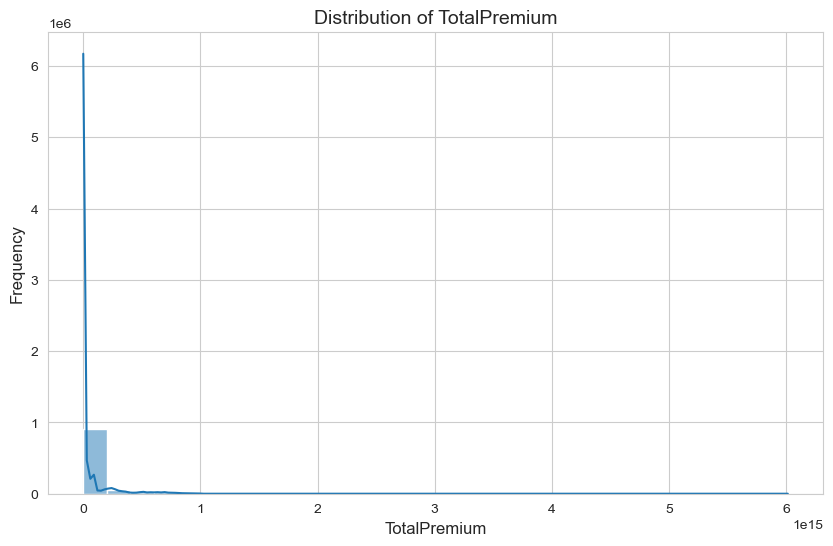

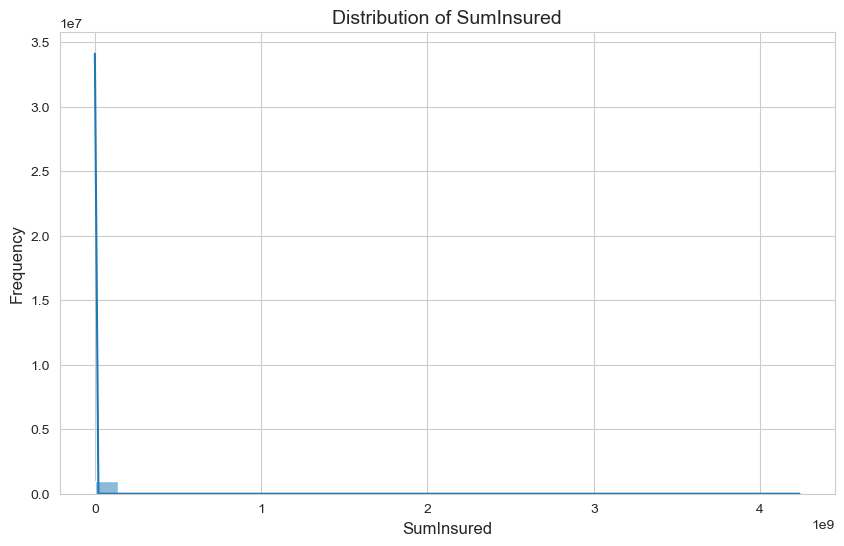

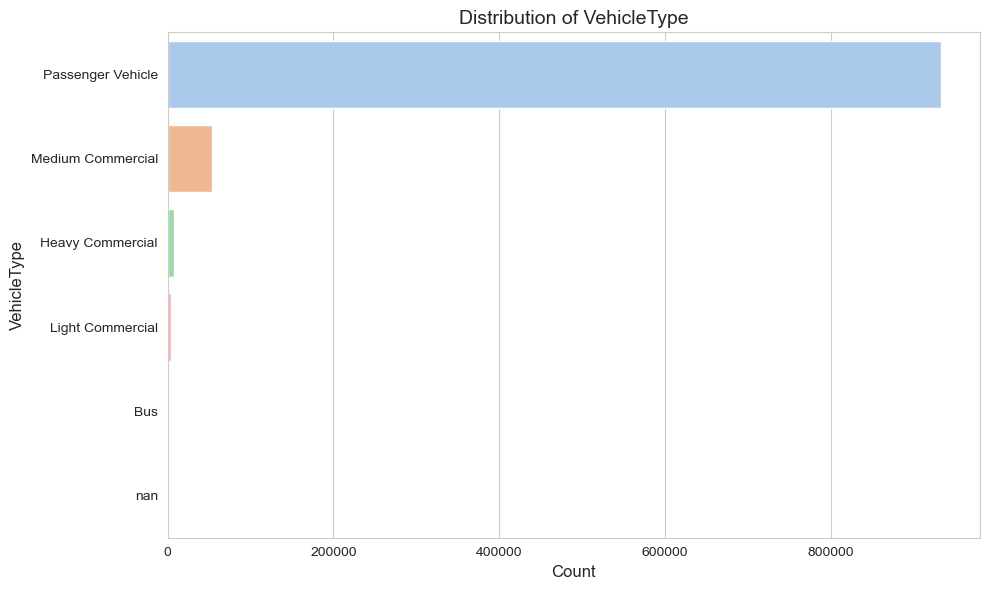

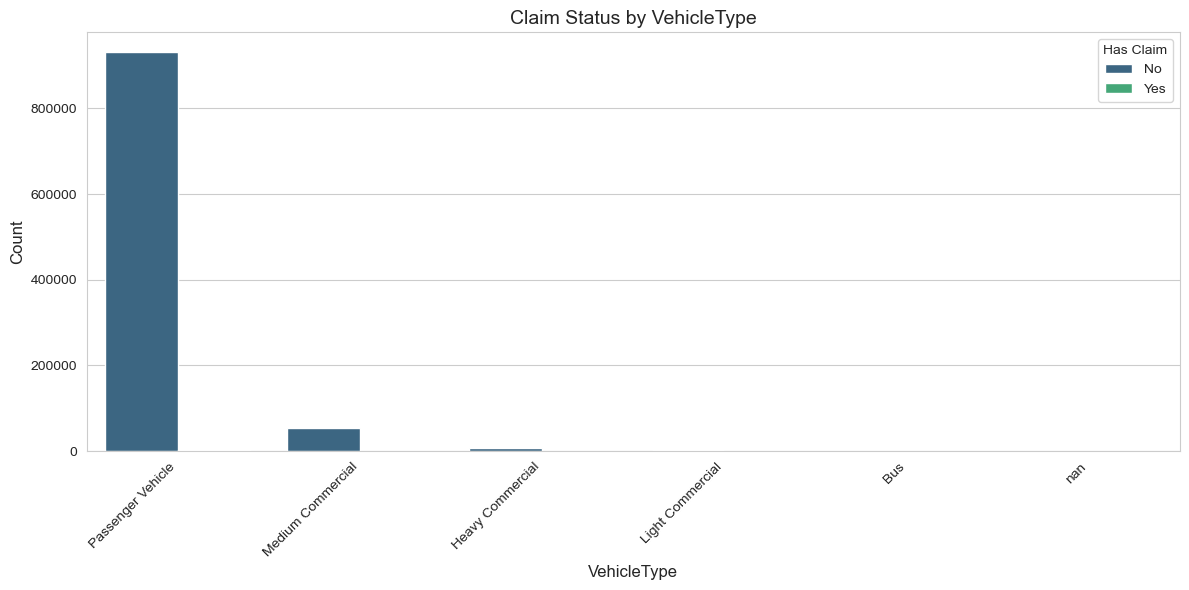


--- Correlation Matrix of Numerical Features ---


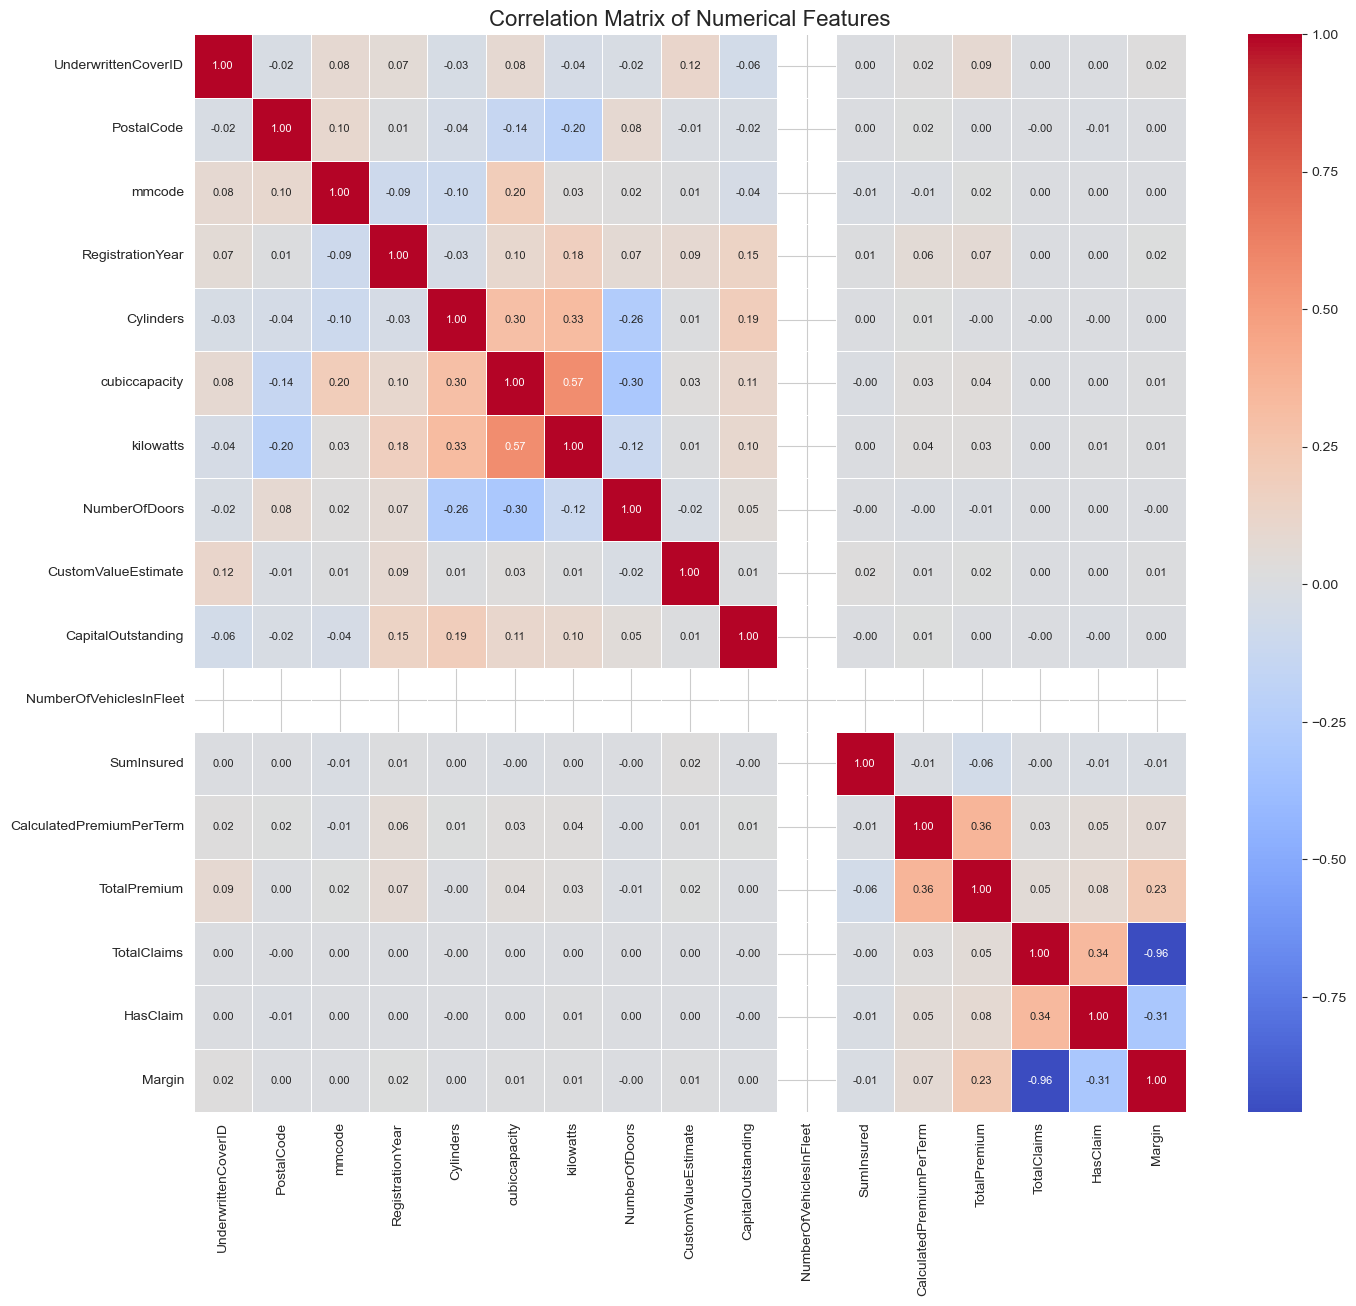


--- EDA Complete ---
This notebook provides a foundational understanding. Further, more specific analyses
can be performed based on initial insights and specific business questions.


In [11]:
print("\n--- Univariate and Bivariate Analysis ---")

# --- Numerical Feature Distributions ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Exclude target/identifier columns if they are in numerical_cols
cols_to_exclude = [TOTAL_CLAIMS_COL, HAS_CLAIM_COL, POLICY_ID_COL, MARGIN_COL]
features_for_dist = [col for col in numerical_cols if col not in cols_to_exclude]

for col in ['Age', 'VehicleAge', 'TotalPremium', 'SumInsured']: # Focus on key numericals
    if col in features_for_dist:
        plt.figure(figsize=(10, 6))
        sns.histplot(df[col], bins=30, kde=True)
        plt.title(f'Distribution of {col}', fontsize=14)
        plt.xlabel(col, fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        plt.show()


# --- Categorical Feature Distributions ---
categorical_cols = df.select_dtypes(include='object').columns.tolist()
# Exclude identifier columns
cat_cols_for_plot = [col for col in categorical_cols if col != POLICY_ID_COL]

for col in ['PolicyType', 'DriverGender', 'VehicleType', 'FuelType']: # Focus on key categoricals
    if col in cat_cols_for_plot:
        plt.figure(figsize=(10, 6))
        sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='pastel')
        plt.title(f'Distribution of {col}', fontsize=14)
        plt.xlabel('Count', fontsize=12)
        plt.ylabel(col, fontsize=12)
        plt.tight_layout()
        plt.show()


# --- Bivariate Analysis: Categorical vs. Target (HasClaim) ---
if HAS_CLAIM_COL in df.columns:
    for col in ['PolicyType', 'DriverGender', 'VehicleType']: # Examples
        if col in cat_cols_for_plot:
            plt.figure(figsize=(12, 6))
            sns.countplot(x=col, hue=HAS_CLAIM_COL, data=df, palette='viridis')
            plt.title(f'Claim Status by {col}', fontsize=14)
            plt.xlabel(col, fontsize=12)
            plt.ylabel('Count', fontsize=12)
            plt.xticks(rotation=45, ha='right')
            plt.legend(title='Has Claim', labels=['No', 'Yes'])
            plt.tight_layout()
            plt.show()


# --- Correlation Matrix for Numerical Features ---
print("\n--- Correlation Matrix of Numerical Features ---")
# Select only numeric columns for correlation (excluding identifiers like PolicyID)
numeric_df = df.select_dtypes(include=np.number)
if POLICY_ID_COL in numeric_df.columns:
    numeric_df = numeric_df.drop(columns=[POLICY_ID_COL])

if not numeric_df.empty:
    correlation_matrix = numeric_df.corr()
    plt.figure(figsize=(16, 14)) # Slightly larger for more features
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, annot_kws={"size": 8})
    plt.title('Correlation Matrix of Numerical Features', fontsize=16)
    plt.show()
else:
    print("No numerical columns found for correlation matrix after exclusions.")

print("\n--- EDA Complete ---")
print("This notebook provides a foundational understanding. Further, more specific analyses")
print("can be performed based on initial insights and specific business questions.")

# Univariate Analysis - Numerical Distributions (Histograms)

In [ ]:
numerical_cols = ['TotalPremium', 'TotalClaims', 'CustomValueEstimate', 'CapitalOutstanding',
                  'CalculatedPremiumPerTerm', 'Cylinders', 'cubiccapacity', 'kilowatts',
                  'NumberOfDoors', 'RegistrationYear', 'NumberOfVehiclesInFleet', 'Margin']

# Filter out columns that might not exist or are empty
numerical_cols = [col for col in numerical_cols if col in df.columns]

plt.figure(figsize=(18, 15))
for i, col in enumerate(numerical_cols):
    if i >= len(numerical_cols): # Safety break if subplot count is exceeded
        break
    plt.subplot(4, 4, i + 1)
    sns.histplot(df[col].dropna(), kde=True, bins=30)
    plt.title(f'Distribution of {col}', fontsize=10)
    plt.xlabel(col, fontsize=8)
    plt.ylabel('Frequency', fontsize=8)
    plt.tick_params(axis='both', which='major', labelsize=7)
plt.tight_layout()
plt.suptitle('Univariate Distributions of Numerical Features', y=1.02, fontsize=16)
plt.savefig('../reports/figures/numerical_distributions.png') # Save plot
plt.show()

# Actionable Insight: Note skewness, multi-modality, and ranges.
# For example, TotalClaims likely shows a highly skewed distribution with many zeros.

# Univariate Analysis - Categorical Distributions (Bar Charts)

In [ ]:
categorical_cols = ['Gender', 'Province', 'VehicleType', 'Make', 'Bodytype', 'ExcessSelected',
                    'CoverCategory', 'CoverType', 'Product', 'AlarmImmobiliser', 'TrackingDevice',
                    'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder']

categorical_cols = [col for col in categorical_cols if col in df.columns]


plt.figure(figsize=(18, 20))
for i, col in enumerate(categorical_cols):
    if i >= len(categorical_cols): # Safety break
        break
    plt.subplot(5, 4, i + 1) # Adjust grid as needed
    sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
    plt.title(f'Distribution of {col}', fontsize=10)
    plt.xlabel('Count', fontsize=8)
    plt.ylabel(col, fontsize=8)
    plt.tick_params(axis='both', which='major', labelsize=7)
plt.tight_layout()
plt.suptitle('Univariate Distributions of Categorical Features', y=1.02, fontsize=16)
plt.savefig('../reports/figures/categorical_distributions.png') # Save plot
plt.show()

# Actionable Insight: Identify dominant categories. Are some categories too rare?
# For example, if 'Make' has hundreds of unique values, you might need to group them.

# Bivariate/Multivariate Analysis - Overall Loss Ratio & Variations

In [ ]:
print("\n--- Loss Ratio Analysis ---")

# Calculate overall loss ratio
# Avoid division by zero if TotalPremium sum is 0
overall_loss_ratio = df['TotalClaims'].sum() / df['TotalPremium'].sum() if df['TotalPremium'].sum() > 0 else 0
print(f"Overall Loss Ratio (TotalClaims / TotalPremium): {overall_loss_ratio:.4f}")

# Loss Ratio by Province
province_loss_ratio = df.groupby('Province').agg(
    TotalClaims=('TotalClaims', 'sum'),
    TotalPremium=('TotalPremium', 'sum')
).reset_index()
# Avoid division by zero
province_loss_ratio['Loss_Ratio'] = province_loss_ratio.apply(
    lambda row: row['TotalClaims'] / row['TotalPremium'] if row['TotalPremium'] > 0 else 0, axis=1
)
province_loss_ratio = province_loss_ratio.sort_values(by='Loss_Ratio', ascending=False)
print("\nLoss Ratio by Province:")
display(province_loss_ratio)

plt.figure(figsize=(10, 6))
sns.barplot(x='Loss_Ratio', y='Province', data=province_loss_ratio, palette='coolwarm')
plt.title('Loss Ratio by Province')
plt.xlabel('Loss Ratio')
plt.ylabel('Province')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/loss_ratio_by_province.png')
plt.show()

# Loss Ratio by VehicleType (Top N)
vehicletype_loss_ratio = df.groupby('VehicleType').agg(
    TotalClaims=('TotalClaims', 'sum'),
    TotalPremium=('TotalPremium', 'sum')
).reset_index()
vehicletype_loss_ratio['Loss_Ratio'] = vehicletype_loss_ratio.apply(
    lambda row: row['TotalClaims'] / row['TotalPremium'] if row['TotalPremium'] > 0 else 0, axis=1
)
vehicletype_loss_ratio = vehicletype_loss_ratio.sort_values(by='Loss_Ratio', ascending=False)
# Display top 10 for clarity
print("\nLoss Ratio by VehicleType (Top 10):")
display(vehicletype_loss_ratio.head(10))

# Loss Ratio by Gender
gender_loss_ratio = df.groupby('Gender').agg(
    TotalClaims=('TotalClaims', 'sum'),
    TotalPremium=('TotalPremium', 'sum')
).reset_index()
gender_loss_ratio['Loss_Ratio'] = gender_loss_ratio.apply(
    lambda row: row['TotalClaims'] / row['TotalPremium'] if row['TotalPremium'] > 0 else 0, axis=1
)
print("\nLoss Ratio by Gender:")
display(gender_loss_ratio)

plt.figure(figsize=(6, 4))
sns.barplot(x='Gender', y='Loss_Ratio', data=gender_loss_ratio, palette='pastel')
plt.title('Loss Ratio by Gender')
plt.xlabel('Gender')
plt.ylabel('Loss Ratio')
plt.tight_layout()
plt.savefig('../reports/figures/loss_ratio_by_gender.png')
plt.show()


# Actionable Insight: Provinces with high loss ratios are less profitable, indicating higher risk.
# Vehicle types with high loss ratios are also higher risk.

# Temporal Trends

In [ ]:
print("\n--- Temporal Trends Analysis ---")

# Aggregate by TransactionMonth
monthly_data = df.groupby('TransactionMonth').agg(
    TotalClaims=('TotalClaims', 'sum'),
    TotalPremium=('TotalPremium', 'sum'),
    NumPolicies=('PolicyID', 'nunique'), # Count unique policies per month
    NumClaimsOccurred=('HasClaim', 'sum') # Count policies that had a claim
).reset_index()

# Calculate Claim Frequency Rate (policies with claims / total policies)
monthly_data['Claim_Frequency_Rate'] = (monthly_data['NumClaimsOccurred'] / monthly_data['NumPolicies']).fillna(0)

# Calculate Average Claim Severity (TotalClaims / NumClaimsOccurred) for claims-only policies
# Need to join with claims_df or recalculate more carefully. For simplicity here:
# Average severity across all policies (including 0 claim policies)
monthly_data['Average_Claim_Amount_Per_Policy'] = (monthly_data['TotalClaims'] / monthly_data['NumPolicies']).fillna(0)
# If you want severity ONLY for policies with claims:
df_claims_only = df[df['TotalClaims'] > 0].copy()
monthly_severity_claims_only = df_claims_only.groupby('TransactionMonth')['TotalClaims'].mean().reset_index()
monthly_data = monthly_data.merge(monthly_severity_claims_only, on='TransactionMonth', how='left', suffixes=('', '_Severity_ClaimsOnly'))
monthly_data['TotalClaims_Severity_ClaimsOnly'] = monthly_data['TotalClaims_Severity_ClaimsOnly'].fillna(0)


plt.figure(figsize=(14, 7))
sns.lineplot(x='TransactionMonth', y='TotalPremium', data=monthly_data, label='Total Monthly Premium', marker='o')
sns.lineplot(x='TransactionMonth', y='TotalClaims', data=monthly_data, label='Total Monthly Claims', marker='o')
plt.title('Monthly Trends: Total Premium vs. Total Claims (Feb 2014 - Aug 2015)')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('../reports/figures/monthly_premium_claims_trend.png')
plt.show()


plt.figure(figsize=(14, 7))
sns.lineplot(x='TransactionMonth', y='Claim_Frequency_Rate', data=monthly_data, label='Claim Frequency Rate', marker='o', color='green')
sns.lineplot(x='TransactionMonth', y='TotalClaims_Severity_ClaimsOnly', data=monthly_data, label='Average Claim Severity (Claims Only)', marker='o', color='purple')
plt.title('Monthly Trends: Claim Frequency Rate and Average Claim Severity')
plt.xlabel('Month')
plt.ylabel('Rate / Amount')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('../reports/figures/monthly_freq_severity_trend.png')
plt.show()

# Actionable Insight: Look for seasonality or consistent increases/decreases over the 18 months.

# Vehicle Make/Model Claim Amounts

In [ ]:
print("\n--- Vehicle Make Claim Analysis ---")

# Average claim by Make (only for policies with claims)
make_avg_claims = df_claims_only.groupby('Make')['TotalClaims'].mean().sort_values(ascending=False)

# Consider only Makes with a reasonable number of policies to avoid skewed averages from rare Makes
make_counts = df['Make'].value_counts()
min_policies_for_make_analysis = 50 # Example threshold
common_makes = make_counts[make_counts >= min_policies_for_make_analysis].index
make_avg_claims_filtered = make_avg_claims[make_avg_claims.index.isin(common_makes)]


top_n_makes = 15 # Top N for plotting
bottom_n_makes = 15 # Bottom N for plotting

print(f"\nAverage Claims by Make (Top {top_n_makes} common makes):")
display(make_avg_claims_filtered.head(top_n_makes))
print(f"\nAverage Claims by Make (Bottom {bottom_n_makes} common makes):")
display(make_avg_claims_filtered.tail(bottom_n_makes))


# Plotting top/bottom N common makes
plt.figure(figsize=(15, 8))
sns.barplot(x=make_avg_claims_filtered.head(top_n_makes).index, y=make_avg_claims_filtered.head(top_n_makes).values, palette='Reds_d')
plt.title(f'Top {top_n_makes} Common Makes by Average Claim Amount (Claims Only)')
plt.xlabel('Vehicle Make')
plt.ylabel('Average Claim Amount')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/top_makes_by_avg_claim.png')
plt.show()

plt.figure(figsize=(15, 8))
sns.barplot(x=make_avg_claims_filtered.tail(bottom_n_makes).index, y=make_avg_claims_filtered.tail(bottom_n_makes).values, palette='Greens_d')
plt.title(f'Bottom {bottom_n_makes} Common Makes by Average Claim Amount (Claims Only)')
plt.xlabel('Vehicle Make')
plt.ylabel('Average Claim Amount')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/bottom_makes_by_avg_claim.png')
plt.show()

# Actionable Insight: Identify specific car makes that are associated with higher or lower claim costs.

# Outlier Detection (Box Plots for Financials)

In [ ]:
print("\n--- Outlier Detection for Financial Columns ---")

financial_cols_for_outliers = ['TotalPremium', 'TotalClaims', 'CustomValueEstimate', 'SumInsured', 'CapitalOutstanding', 'Margin']
financial_cols_for_outliers = [col for col in financial_cols_for_outliers if col in df.columns]

plt.figure(figsize=(18, 10))
for i, col in enumerate(financial_cols_for_outliers):
    if i >= len(financial_cols_for_outliers): # Safety break
        break
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col, fontsize=8)
    plt.tick_params(axis='y', which='major', labelsize=7)
plt.tight_layout()
plt.suptitle('Outlier Detection in Financial Features', y=1.02, fontsize=16)
plt.savefig('../reports/figures/financial_outliers_boxplots.png')
plt.show()

# Actionable Insight: Understand the range and presence of extreme values, especially in TotalClaims,
# which can heavily influence averages and models. Decide on a strategy for handling them later (capping, transformation).

# Creative and Beautiful Plots (Examples)

In [ ]:
# Produce 3 creative and beautiful plots that capture key insights.
# These plots should be chosen based on the most impactful findings from your EDA.

# Example 1: Combined Loss Ratio by Province and Gender
# Using melt for easier plotting if needed, or direct barplots.

df_grouped_loss_gender_province = df.groupby(['Province', 'Gender']).agg(
    TotalClaims=('TotalClaims', 'sum'),
    TotalPremium=('TotalPremium', 'sum')
).reset_index()

df_grouped_loss_gender_province['Loss_Ratio'] = df_grouped_loss_gender_province.apply(
    lambda row: row['TotalClaims'] / row['TotalPremium'] if row['TotalPremium'] > 0 else 0, axis=1
)

plt.figure(figsize=(14, 8))
sns.barplot(x='Province', y='Loss_Ratio', hue='Gender', data=df_grouped_loss_gender_province, palette='deep')
plt.title('Loss Ratio by Province and Gender')
plt.xlabel('Province')
plt.ylabel('Loss Ratio')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')
plt.tight_layout()
plt.savefig('../reports/figures/loss_ratio_province_gender.png')
plt.show()


# Example 2: Distribution of Policies vs. Claims across CoverType
# This helps see where the premium comes from vs where the claims are paid.
cover_type_summary = df.groupby('CoverType').agg(
    NumPolicies=('PolicyID', 'nunique'),
    TotalClaims=('TotalClaims', 'sum'),
    TotalPremium=('TotalPremium', 'sum')
).reset_index()

cover_type_summary['Claim_Ratio_of_Total_Claims'] = cover_type_summary['TotalClaims'] / cover_type_summary['TotalClaims'].sum()
cover_type_summary['Premium_Ratio_of_Total_Premium'] = cover_type_summary['TotalPremium'] / cover_type_summary['TotalPremium'].sum()
cover_type_summary = cover_type_summary.sort_values(by='Premium_Ratio_of_Total_Premium', ascending=False)

fig, ax1 = plt.subplots(figsize=(14, 8))

sns.barplot(x='CoverType', y='Premium_Ratio_of_Total_Premium', data=cover_type_summary, color='skyblue', ax=ax1, label='Proportion of Total Premium')
ax1.set_ylabel('Proportion of Total Premium', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_xlabel('Cover Type')
ax1.set_title('Proportion of Total Premium vs. Claims by Cover Type')
plt.xticks(rotation=45, ha='right')


ax2 = ax1.twinx() # Create a second y-axis
sns.lineplot(x='CoverType', y='Claim_Ratio_of_Total_Claims', data=cover_type_summary, marker='o', color='red', ax=ax2, label='Proportion of Total Claims')
ax2.set_ylabel('Proportion of Total Claims', color='red')
ax2.tick_params(axis='y', labelcolor='red')

fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)
plt.tight_layout()
plt.savefig('../reports/figures/cover_type_premium_claims_proportion.png')
plt.show()


# Example 3: Impact of 'AlarmImmobiliser' and 'TrackingDevice' on Average Claim
# Filter for claims only for severity calculation
df_security_claims = df_claims_only.copy()

# Melt the dataframe to easily plot both security features
df_melted_security = df_security_claims.melt(id_vars=['TotalClaims'], value_vars=['AlarmImmobiliser', 'TrackingDevice'], var_name='Security_Feature', value_name='Has_Feature')

plt.figure(figsize=(12, 7))
sns.boxplot(x='Security_Feature', y='TotalClaims', hue='Has_Feature', data=df_melted_security, palette='Paired')
plt.title('Impact of Security Features on Average Claim Amount (Claims Only)')
plt.xlabel('Security Feature')
plt.ylabel('Total Claim Amount')
plt.yscale('log') # Use log scale if claim amounts vary widely
plt.tight_layout()
plt.savefig('../reports/figures/security_features_claim_impact.png')
plt.show()

print("\n--- EDA complete. Check 'reports/figures/' for generated plots. ---")